# Titanic Survival Prediction —  Machine Learning Workflow

Predicting Passenger Survival on the Titanic Using Machine Learning   

Business Problem : 
The sinking of the Titanic remains one of history's most well-known maritime disasters. Although there was an element of chance, survival was influenced by several factors such as passenger class, age, gender, family size, and fare paid.
The goal of this project is to build a machine learning model that predicts whether a passenger survived based on available passenger information.

Problem Statement : Can we accurately predict whether a passenger survived the Titanic disaster using demographic and travel-related characteristics?

Objectives

1. Clean and prepare the Titanic dataset

2. Handle missing values

3. Convert categorical variables into numerical features

4. Scale numerical features

5. Split the data into training and testing datasets

6. Train multiple classification models

7. Compare model performance

8. Identify the most important factors affecting survival


Dataset

Typical features include:

Feature	:        Description

PassengerId :	    Passenger identifier

Survived	:     Target variable (0 = No, 1 = Yes)

Pclass	 :       Passenger class

Name	   :     Passenger name

Sex	       :     Male/Female

Age	       :     Passenger age

SibSp	   :     Number of siblings/spouses aboard

Parch	    :    Number of parents/children aboard

Ticket	    :    Ticket number

Fare	   :     Ticket fare

Cabin	   :     Cabin number

Embarked	:    Port of embarkation

## Step 1 — Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

RANDOM_STATE = 42

## Step 2 — Load the dataset

In [2]:
# Update this path for your computer.
DATA_PATH = r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\Feature Engineering\titanic.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (891, 12)


,passengerId,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3 — Initial data exploration

In [3]:
df.info()
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerId  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
passengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292



Missing values:


cabin          687
age            177
embarked         2
passengerId      0
name             0
pclass           0
survived         0
sex              0
parch            0
sibsp            0
fare             0
ticket           0
dtype: int64

## Step 4 — Exploratory Data Analysis

Exploring the dataset by answering questions such as:

How many passengers survived?
Does gender affect survival?
Did first-class passengers survive more often?
What age groups had the highest survival rates?
Does fare correlate with survival?
Which embarkation port had the highest survival rate.
Learned preprocessing values such as medians, modes, and scaling parameters are **not** calculated here.

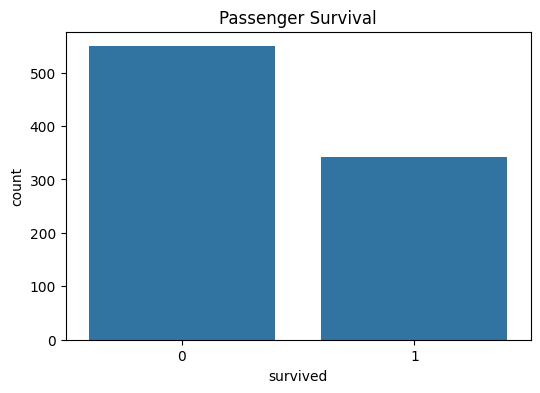

In [4]:
plt.figure(figsize=(6,4)); sns.countplot(data=df, x="survived"); plt.title("Passenger Survival"); plt.show()

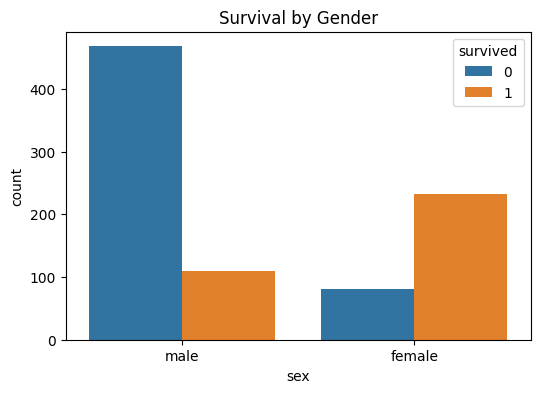

In [5]:
plt.figure(figsize=(6,4)); sns.countplot(data=df, x="sex", hue="survived"); plt.title("Survival by Gender"); plt.show()

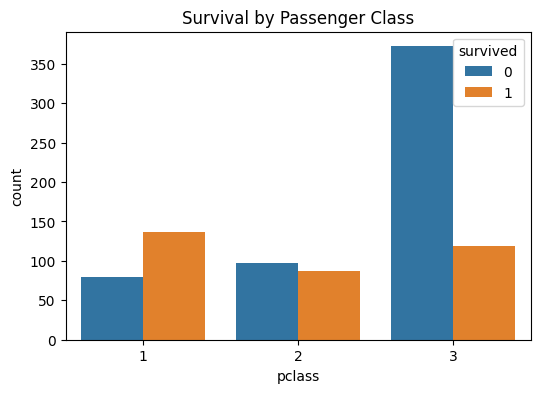

In [6]:
plt.figure(figsize=(6,4)); sns.countplot(data=df, x="pclass", hue="survived"); plt.title("Survival by Passenger Class"); plt.show()

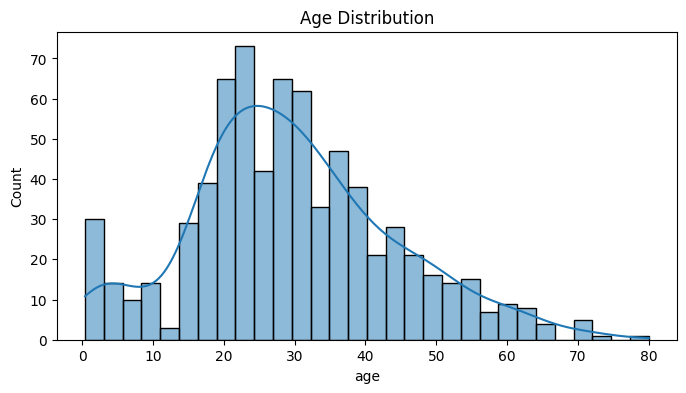

In [7]:
plt.figure(figsize=(8,4)); sns.histplot(data=df, x="age", bins=30, kde=True); plt.title("Age Distribution"); plt.show()

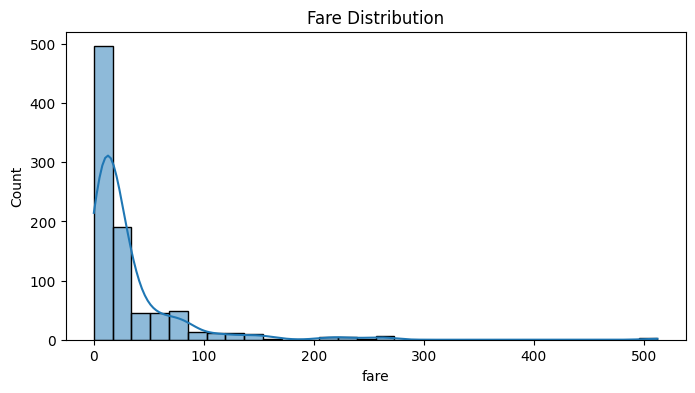

In [8]:
plt.figure(figsize=(8,4)); sns.histplot(data=df, x="fare", bins=30, kde=True); plt.title("Fare Distribution"); plt.show()

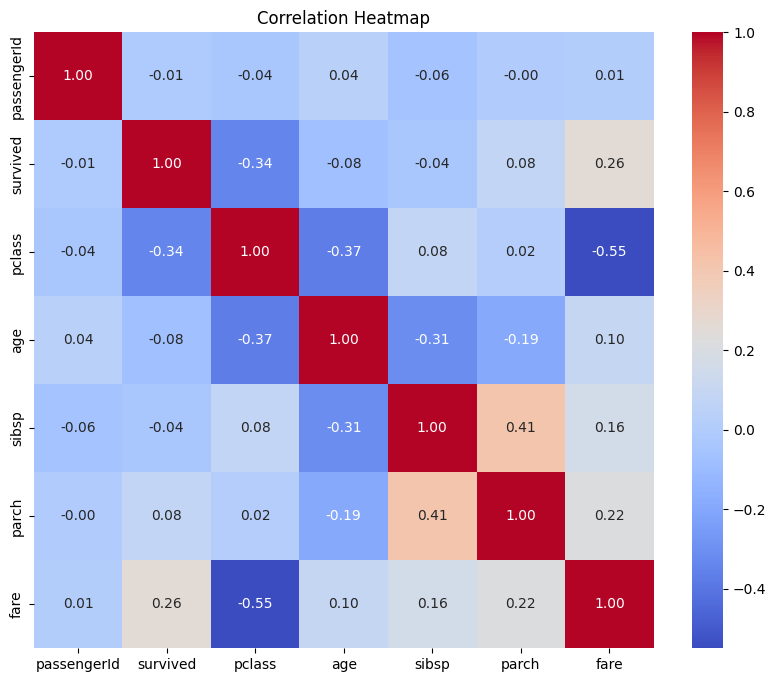

In [9]:
numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8)); sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f"); plt.title("Correlation Heatmap"); plt.show()

## Step 5 — Feature engineering

Deterministic record-level features can be created before the split. Missing-value imputation, encoding, and scaling are deliberately left for the modeling pipeline.

In [10]:
def add_features(data):
    data = data.copy()
    data["family_size"] = data["sibsp"] + data["parch"] + 1
    data["is_alone"] = (data["family_size"] == 1).astype(int)
    if "name" in data.columns:
        data["title"] = data["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
        rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
        data["title"] = data["title"].replace(rare_titles, "Rare")
        data["title"] = data["title"].replace({"Mlle":"Miss", "Ms":"Miss"})
    data = data.drop(columns=[c for c in ["name","ticket","cabin"] if c in data.columns])
    return data

df_model = add_features(df)
display(df_model.head())

,passengerId,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone,title
0,1,0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,3,1,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,5,0,3,male,35.0,0,0,8.0500,S,1,1,Mr


## Step 6 — Separate target and split once

This is the critical correction. The test set is isolated before any learned preprocessing.

In [11]:
X = df_model.drop(columns="survived")
y = df_model["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).rename("proportion"))
print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).rename("proportion"))

Training set: (668, 11)
Test set: (223, 11)

Training target distribution:


survived
0    0.616766
1    0.383234
Name: proportion, dtype: float64


Test target distribution:


survived
0    0.61435
1    0.38565
Name: proportion, dtype: float64

## Step 7 — Build the preprocessing pipeline

Numeric variables use median imputation followed by scaling. Categorical variables use most-frequent imputation followed by one-hot encoding. The fitted transformations are learned only from training folds during cross-validation.

In [12]:
numeric_features = [c for c in ["age","fare","sibsp","parch","family_size","is_alone"] if c in X_train.columns]
categorical_features = [c for c in ["pclass","sex","embarked","title"] if c in X_train.columns]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'fare', 'sibsp', 'parch', 'family_size', 'is_alone']
Categorical features: ['pclass', 'sex', 'embarked', 'title']


## Step 8 — Candidate models

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE)
}

## Step 9 — Cross-validation on training data

The test set remains untouched. Five-fold stratified cross-validation provides a more stable development estimate.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "precision":"precision", "recall":"recall", "f1":"f1", "roc_auc":"roc_auc"}
cv_results = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
display(cv_results_df)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.815823,0.780230,0.726244,0.750983,0.862567
1,Random Forest,0.805353,0.754033,0.741855,0.745315,0.855003
2,Support Vector Machine,0.827808,0.823380,0.703092,0.758006,0.848466
3,KNN,0.788935,0.745052,0.687406,0.714336,0.831434
4,Decision Tree,0.765010,0.685844,0.722700,0.703020,0.756153


## Step 10 — Hyperparameter tuning

Tune Random Forest using only the training set and cross-validation. The test set is still untouched.

In [15]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest mean CV ROC-AUC:", round(grid_search.best_score_, 4))
best_model = grid_search.best_estimator_

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best mean CV ROC-AUC: 0.8699


## Step 11 — Final held-out test evaluation

The test set is used here for the first and only final evaluation.

In [16]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}])
display(final_metrics)

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.811659,0.814286,0.662791,0.730769,0.850874


In [17]:
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

                 precision    recall  f1-score   support

Did not survive       0.81      0.91      0.86       137
       Survived       0.81      0.66      0.73        86

       accuracy                           0.81       223
      macro avg       0.81      0.78      0.79       223
   weighted avg       0.81      0.81      0.81       223



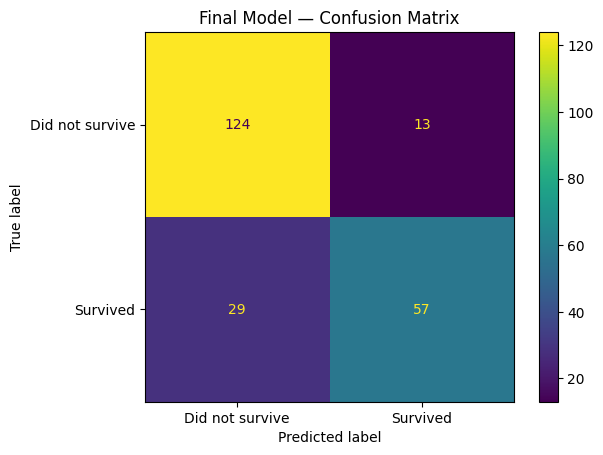

In [18]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive","Survived"]).plot()
plt.title("Final Model — Confusion Matrix")
plt.show()

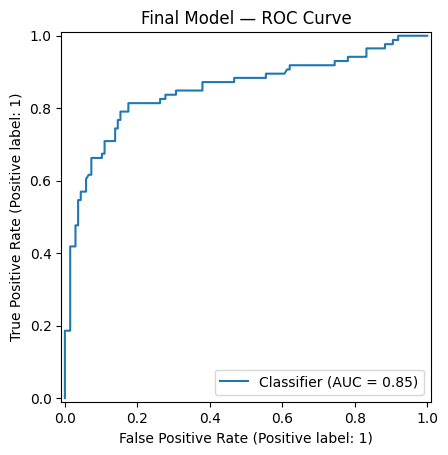

In [19]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Final Model — ROC Curve")
plt.show()

## Step 12 — Compare candidate models

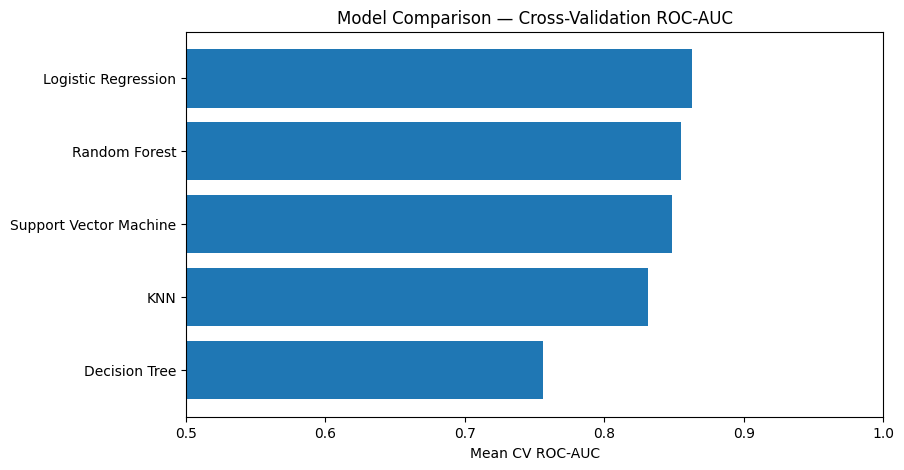

In [20]:
plot_df = cv_results_df.sort_values("CV ROC-AUC", ascending=True)
plt.figure(figsize=(9,5))
plt.barh(plot_df["Model"], plot_df["CV ROC-AUC"])
plt.xlabel("Mean CV ROC-AUC")
plt.title("Model Comparison — Cross-Validation ROC-AUC")
plt.xlim(0.5, 1.0)
plt.show()

## Step 13 — Predictive feature importance

Feature importance is interpreted as importance to the fitted Random Forest's predictions, **not as proof that a feature causes survival**.

In [21]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_rf = best_model.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()
importance = pd.Series(fitted_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
display(importance.head(15).to_frame("importance"))

,importance
num__fare,0.192829
cat__title_Mr,0.173767
cat__sex_male,0.162512
num__age,0.143368
cat__pclass_3,0.070051
num__family_size,0.052082
cat__title_Miss,0.048152
cat__title_Mrs,0.042735
num__sibsp,0.028022
num__parch,0.023223


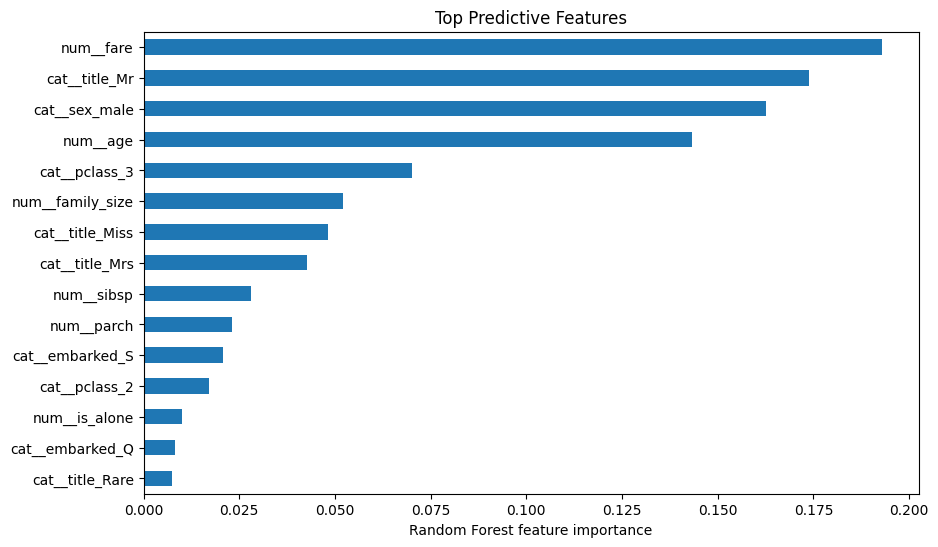

In [22]:
plt.figure(figsize=(10,6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Random Forest feature importance")
plt.title("Top Predictive Features")
plt.show()

## Step 14 — Predict a genuinely new passenger

The example below is not selected from the dataset. The raw record is passed through the same fitted pipeline used during training.

In [23]:
new_passenger = pd.DataFrame([{
    "pclass": 3, "sex": "male", "age": 30, "sibsp": 0, "parch": 0,
    "fare": 8.50, "embarked": "S", "name": "Example Passenger",
    "ticket": "NEW", "cabin": np.nan
}])

new_passenger = add_features(new_passenger)
prediction = best_model.predict(new_passenger)[0]
probability = best_model.predict_proba(new_passenger)[0, 1]

print("Predicted outcome:", "SURVIVED" if prediction == 1 else "DID NOT SURVIVE")
print(f"Predicted probability of survival: {probability:.2%}")

Predicted outcome: DID NOT SURVIVE
Predicted probability of survival: 24.32%


In [31]:
#which model is best model based on the cross-validation ROC-AUC score?
best_model = cv_results_df.loc[cv_results_df["CV ROC-AUC"].idxmax()]
print("Best Model:")
print(best_model)

#which model is best model based on prediction for new passenger?
new_passenger_prediction = best_model["Model"]
print("New Passenger Prediction:")
print(new_passenger_prediction)

Best Model:
Model           Logistic Regression
CV Accuracy                0.815823
CV Precision                0.78023
CV Recall                  0.726244
CV F1                      0.750983
CV ROC-AUC                 0.862567
Name: 0, dtype: object
New Passenger Prediction:
Logistic Regression


## Step 15 — Final conclusions

The workflow demonstrates: (1) one stratified train/test split, (2) preprocessing inside a Pipeline, (3) training-only imputation/scaling/encoding, (4) cross-validation, (5) hyperparameter tuning without test-set exposure, (6) final out-of-sample evaluation, (7) multiple classification metrics, and (8) consistent preprocessing for future predictions.

### Key lesson
After preprocessing the Titanic dataset and training several classification models, the Logistic Regression achieved the highest predictive performance. The analysis showed that gender, passenger class, fare paid, age, and family size were among the strongest predictors of survival. This project demonstrates how data preprocessing—including handling missing values, encoding categorical variables, scaling numerical features, and engineering new features—can significantly improve model performance and produce actionable insights from historical data.